<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Credit Model

<font color='black'>

- Ivanna herrera Ibarra
- Ana Sofía Hinojosa Bale
- Luis Fernando Márquez Bañuelos

In [1]:
import os
import shap
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report, ConfusionMatrixDisplay

np.random.seed(42)
warnings.filterwarnings('ignore')

## <font color='cornflowerblue'> Functions

In [2]:
def curva_roc(probabilidades: np.ndarray, y_test: np.ndarray) -> float:
        """
        Analyzes the ROC curve to find the optimal threshold and visualizes it.

        Args:
                probabilidades (np.ndarray): Predicted probabilities of the positive class.
                y_test (np.ndarray): True binary labels for the test set.

        Returns:
                float: Optimal threshold value.
        """
        fpr, tpr, thresholds = roc_curve(y_score=probabilidades, y_true=y_test)

        distances   = np.sqrt(fpr**2 + (1 - tpr)**2)
        best_idx    = np.argmin(distances)
        best_thr    = thresholds[best_idx]
        best_fpr    = fpr[best_idx]
        best_tpr    = tpr[best_idx]
        auc_score   = roc_auc_score(y_test, probabilidades)

        fig, ax = plt.subplots(figsize=(9, 5))

        # Área bajo la curva sombreada
        ax.fill_between(fpr, tpr, alpha=0.08, color='#2E86AB')

        ax.plot(fpr, tpr, color='#2E86AB', lw=2,
                label=f'AUC = {auc_score:.3f}')
        ax.plot([0, 1], [0, 1], color='#E84855', lw=1.5,
                linestyle='--', label='Random classifier')

        # Líneas guía al mejor threshold
        ax.plot([best_fpr, best_fpr], [0, best_tpr],
                color='#F4A261', lw=1, linestyle=':')
        ax.plot([0, best_fpr], [best_tpr, best_tpr],
                color='#F4A261', lw=1, linestyle=':')

        # Estrella
        ax.scatter(best_fpr, best_tpr, marker='*', s=400,
                color='#F4A261', zorder=5,
                label=f'Best threshold = {best_thr:.3f}\n'
                        f'FPR={best_fpr:.3f}  TPR={best_tpr:.3f}')

        ax.set_xlim(-0.01, 1.01)
        ax.set_ylim(-0.01, 1.01)
        ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
        ax.set_ylabel('True Positive Rate (Sensitivity)',      fontsize=11)
        ax.set_title('ROC Curve — Credit Default XGBoost',
                        fontsize=13, fontweight='bold', pad=12)
        ax.legend(fontsize=10, framealpha=0.9, loc='lower right')

        plt.tight_layout()
        plt.show()

        return best_thr


def lgd_hipotecario(ead: np.ndarray, 
                    property_value: np.ndarray,
                    haircut: float = 0.25) -> np.ndarray: #HAIRCUT INVESTIGAR
        """
        Computes LGD for mortgage loans based on collateral recovery.

        At default, the bank recovers the property value minus execution costs
        (legal fees, foreclosure costs, fire-sale discount) modeled as a haircut.

        Recovery = min(EAD, VALUE * (1 - haircut))
        LGD = max(0, 1 - Recovery / EAD)

        Args:
                ead (np.ndarray): Outstanding balance at default (EAD), shape (n,).
                property_value (np.ndarray): Appraised value of the mortgaged property, shape (n,).
                haircut (float): Foreclosure cost as fraction of property value (default 25%).

        Returns:
                np.ndarray: LGD values in [0, 1], shape (n,).
        """
        net_recovery = property_value * (1 - haircut)
        # Bank can only recover up to what is owed
        actual_recovery = np.minimum(ead, net_recovery)
        lgd = 1 - (actual_recovery / ead)
        return np.clip(lgd, 0, 1)


def amortization(principal: float | pd.Series, annual_rate: float, months: int) -> float:
    """
    Generates an amortization schedule for a loan.

    Args:
        principal (float | pd.Series): The initial amount of the loan.
        annual_rate (float): The annual interest rate.
        months (int): The total number of monthly payments.

    Returns:
        float: The total amount paid over the life of the loan.
    """
    annual_rate = annual_rate / 100  # Convert percentage to decimal
    monthly_rate = annual_rate / 12
    payment = principal * (monthly_rate / (1 - (1 + monthly_rate) ** -months))

    return payment * months

## <font color='cornflowerblue'> Data

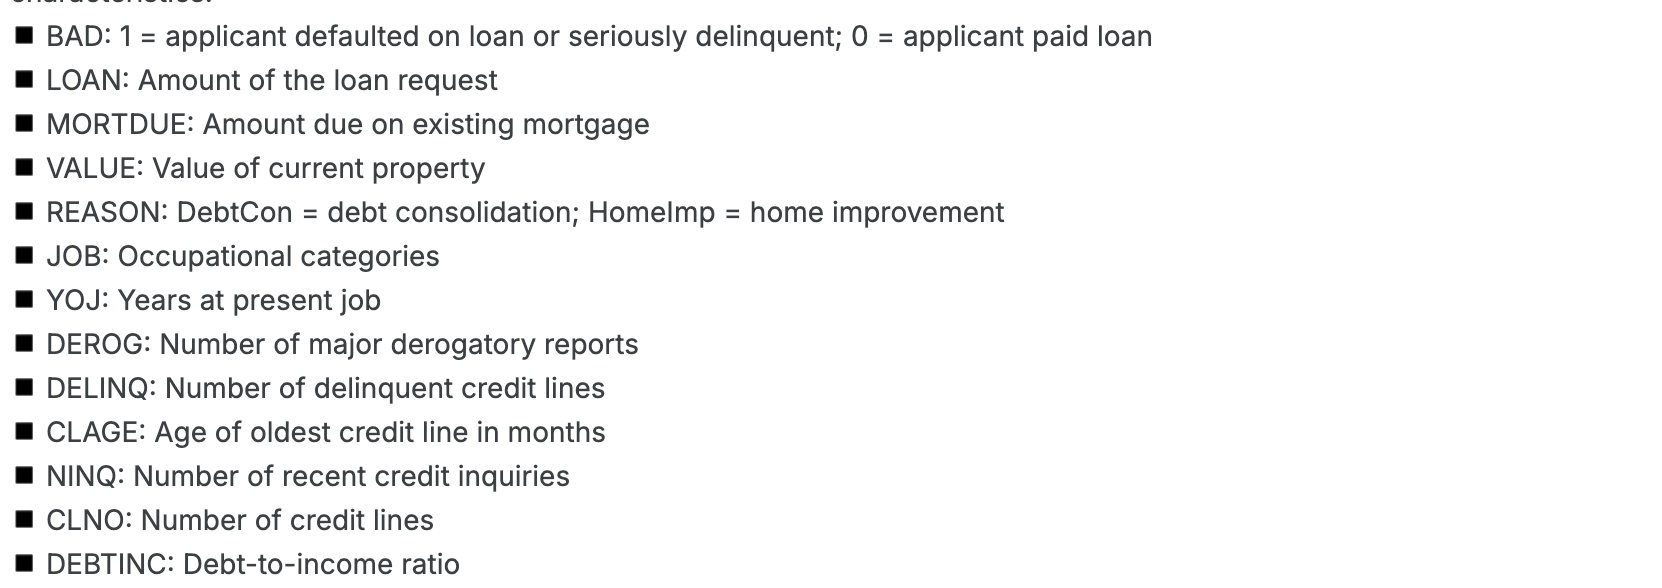

In [3]:
# NOTE: LOAN represents the new credit requested by the applicant.
# We assume the existing mortgage (MORTDUE) is already held by our bank.
# Therefore:
#   - EAD = MORTDUE (current outstanding exposure)
#   - LOAN is retained only as a feature for PD estimation (LTV, CLTV)
#   - LOAN does not enter the EL calculation
# The model only works with people that already had or currently have a mortgage.

# Load the HMEQ dataset from Kaggle
data = pd.read_csv('hmeq_cleaned.csv')
data

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,JOB_Mgr,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self
0,1.0,1100.0,25860.0,39025.0,10.5,0,0.0,94.366667,1.0,9.0,35.066557,False,False,True,False,False,False
1,1.0,1300.0,70053.0,68400.0,7.0,0,2.0,121.833333,0.0,14.0,37.350179,False,False,True,False,False,False
2,1.0,1500.0,13500.0,16700.0,4.0,0,0.0,149.466667,1.0,10.0,36.583777,False,False,True,False,False,False
3,0.0,1700.0,97800.0,112000.0,3.0,0,0.0,93.333333,0.0,14.0,30.481097,False,True,False,False,False,False
4,1.0,1700.0,30548.0,40320.0,9.0,0,0.0,101.466002,1.0,8.0,37.113614,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5437,0.0,88900.0,57264.0,90185.0,16.0,0,0.0,221.808718,0.0,16.0,36.112347,False,False,True,False,False,False
5438,0.0,89000.0,54576.0,92937.0,16.0,0,0.0,208.692070,0.0,15.0,35.859971,False,False,True,False,False,False
5439,0.0,89200.0,54045.0,92924.0,15.0,0,0.0,212.279697,0.0,15.0,35.556590,False,False,True,False,False,False
5440,0.0,89800.0,50370.0,91861.0,14.0,0,0.0,213.892709,0.0,16.0,34.340882,False,False,True,False,False,False


## <font color='cornflowerblue'> Benchmark

              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91       872
         1.0       0.82      0.27      0.40       217

    accuracy                           0.84      1089
   macro avg       0.83      0.63      0.66      1089
weighted avg       0.84      0.84      0.81      1089



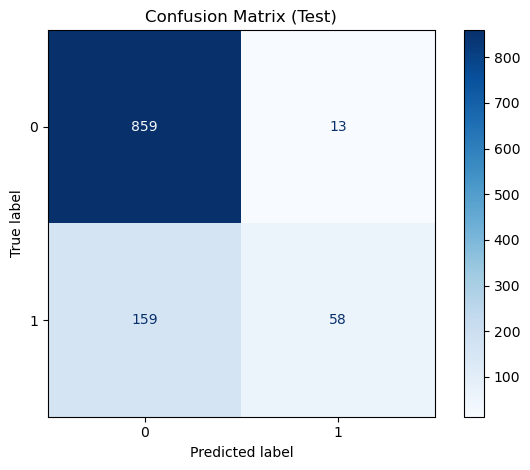

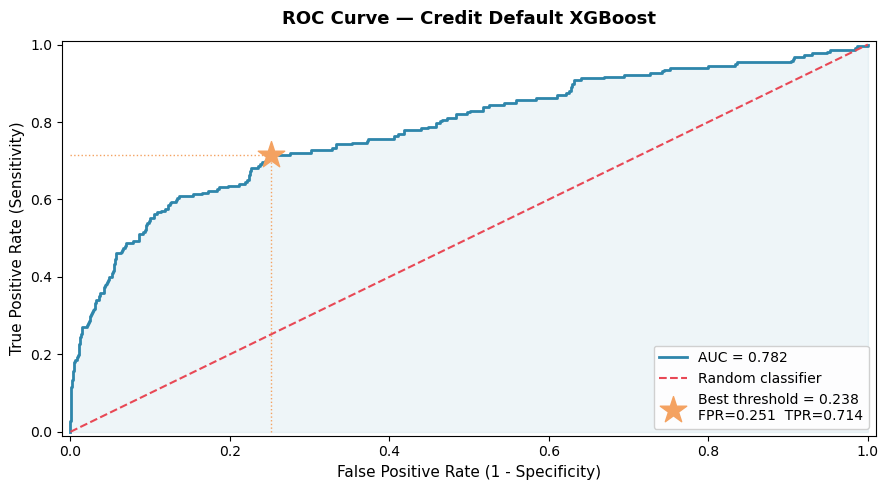

In [4]:
# Defining the target variable
target = 'BAD'

X = data.copy()
# Drop target and features that may cause data leakage or are not relevant for PD estimation
X = X.drop(columns=[target])
y = data[target]

# Split the dataset into training and testing sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Logistic Regression
model_log = LogisticRegression()
model_log.fit(X_train, y_train)

# Predictions
y_pred = model_log.predict(X_test)
y_pred_proba = model_log.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

thr = curva_roc(y_pred_proba, y_test)

## <font color='cornflowerblue'> Feature Engineering

In [5]:
# Nivel de apalancamiento total
data['TOTAL_DEBT'] = data['LOAN'] + data['MORTDUE']

# Loan-to-Value: qué tan apalancado está el crédito vs. el inmueble
data['LTV'] = data['LOAN'] / data['VALUE']

# Combined LTV: suma deuda nueva + deuda hipotecaria existente sobre el valor
data['CLTV'] = data['TOTAL_DEBT'] / data['VALUE']

# Equity del propietario: qué tanto del inmueble es "suyo"
data['HOME_EQUITY'] = data['VALUE'] - data['MORTDUE']

# Equity ratio
data['EQUITY_RATIO'] = data['HOME_EQUITY'] / data['VALUE']

# Ratio de líneas delinquentes sobre total
data['DELINQ_RATIO'] = data['DELINQ'] / (data['CLNO'] + 1)  # +1 evita división por 0

# Equity negativo (underwater): deuda > valor del inmueble
data['UNDERWATER'] = (data['TOTAL_DEBT'] > data['VALUE']).astype(int)

data

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,...,JOB_ProfExe,JOB_Sales,JOB_Self,TOTAL_DEBT,LTV,CLTV,HOME_EQUITY,EQUITY_RATIO,DELINQ_RATIO,UNDERWATER
0,1.0,1100.0,25860.0,39025.0,10.5,0,0.0,94.366667,1.0,9.0,...,False,False,False,26960.0,0.028187,0.690839,13165.0,0.337348,0.000000,0
1,1.0,1300.0,70053.0,68400.0,7.0,0,2.0,121.833333,0.0,14.0,...,False,False,False,71353.0,0.019006,1.043173,-1653.0,-0.024167,0.133333,1
2,1.0,1500.0,13500.0,16700.0,4.0,0,0.0,149.466667,1.0,10.0,...,False,False,False,15000.0,0.089820,0.898204,3200.0,0.191617,0.000000,0
3,0.0,1700.0,97800.0,112000.0,3.0,0,0.0,93.333333,0.0,14.0,...,False,False,False,99500.0,0.015179,0.888393,14200.0,0.126786,0.000000,0
4,1.0,1700.0,30548.0,40320.0,9.0,0,0.0,101.466002,1.0,8.0,...,False,False,False,32248.0,0.042163,0.799802,9772.0,0.242361,0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5437,0.0,88900.0,57264.0,90185.0,16.0,0,0.0,221.808718,0.0,16.0,...,False,False,False,146164.0,0.985752,1.620713,32921.0,0.365039,0.000000,1
5438,0.0,89000.0,54576.0,92937.0,16.0,0,0.0,208.692070,0.0,15.0,...,False,False,False,143576.0,0.957638,1.544874,38361.0,0.412763,0.000000,1
5439,0.0,89200.0,54045.0,92924.0,15.0,0,0.0,212.279697,0.0,15.0,...,False,False,False,143245.0,0.959924,1.541529,38879.0,0.418396,0.000000,1
5440,0.0,89800.0,50370.0,91861.0,14.0,0,0.0,213.892709,0.0,16.0,...,False,False,False,140170.0,0.977564,1.525892,41491.0,0.451672,0.000000,1


In [6]:
# Defining the target variable
target = 'BAD'

X = data.copy()
# Drop target and features that may cause data leakage or are not relevant for PD estimation
X = X.drop(columns=[target, 'HOME_EQUITY', 'TOTAL_DEBT'])
y = data[target]

# Split the dataset into training and testing sets with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## <font color='cornflowerblue'> Model: XGBoost

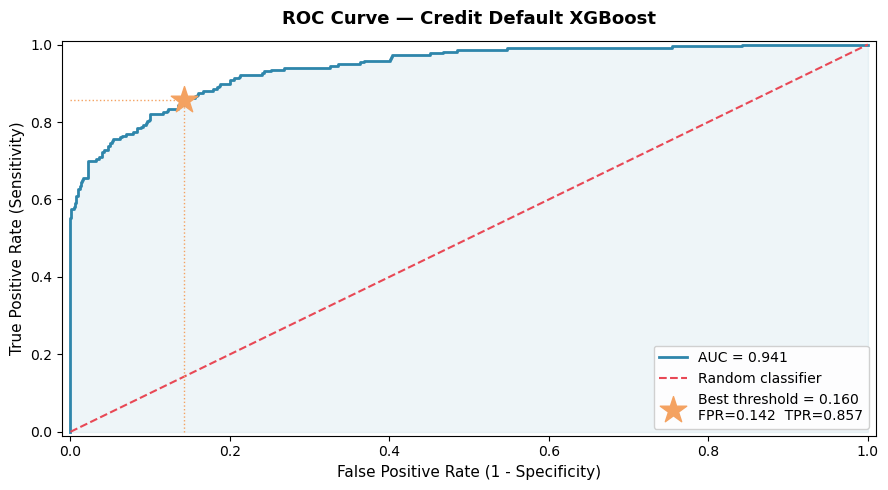

In [7]:
# XGBoost
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    min_child_weight=3,
    subsample=0.6,
    colsample_bytree=0.6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=0
)

# Predictions and probabilities
y_proba_log = model.predict_proba(X_test)[:, 1]
best_thr = curva_roc(y_proba_log, y_test)

In [8]:
# Create a test set DataFrame for analysis
data_test = pd.concat([X_test, y_test], axis=1)

data_test['LGD'] = lgd_hipotecario(
    ead            = data_test['MORTDUE'].values,
    property_value = data_test['VALUE'].values,
    haircut        = 0.25
)

data_test

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,JOB_ProfExe,JOB_Sales,JOB_Self,LTV,CLTV,EQUITY_RATIO,DELINQ_RATIO,UNDERWATER,BAD,LGD
1061,10100.0,68820.0,78830.0,2.000000,0,0.0,170.722452,1.0,34.0,29.206753,...,False,False,False,0.128124,1.001142,0.126982,0.0,1,0.0,0.140911
3817,21700.0,24771.0,48361.0,0.000000,0,0.0,309.028445,1.0,24.0,33.877264,...,False,False,False,0.448709,0.960919,0.487790,0.0,0,0.0,0.000000
2357,15000.0,27954.0,79333.0,3.076486,0,0.0,256.003805,1.0,49.0,42.581949,...,False,False,False,0.189076,0.541439,0.647637,0.0,0,0.0,0.000000
3555,20300.0,37388.0,55703.0,6.966978,0,0.0,222.733567,0.0,12.0,39.814737,...,False,False,False,0.364433,1.035635,0.328797,0.0,1,0.0,0.000000
4180,23900.0,70694.0,95718.0,11.000000,0,0.0,138.167360,0.0,13.0,38.561206,...,False,False,False,0.249692,0.988257,0.261435,0.0,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954,22400.0,91402.0,100845.0,2.000000,1,0.0,132.216622,0.0,20.0,35.682471,...,True,False,False,0.222123,1.128484,0.093639,0.0,1,0.0,0.172515
3235,18700.0,58498.0,90135.0,30.000000,0,0.0,199.109272,0.0,21.0,33.182239,...,False,False,False,0.207467,0.856471,0.350996,0.0,0,0.0,0.000000
3704,21200.0,130373.0,204384.0,13.000000,0,0.0,197.044461,0.0,21.0,35.204435,...,True,False,False,0.103726,0.741609,0.362117,0.0,0,0.0,0.000000
5296,47600.0,39364.0,108232.0,9.000000,0,0.0,199.333286,2.0,35.0,40.189422,...,False,False,True,0.439796,0.803496,0.636300,0.0,0,0.0,0.000000


In [9]:
# Add probabilities and calculate expected loss
data_test['default_proba'] = y_proba_log
data_test['EL_pct'] = data_test['default_proba'] * data_test['LGD']
data_test['EL_amount'] = data_test['default_proba'] * data_test['LGD'] * data_test['MORTDUE']

# Results
portfolio = data_test['MORTDUE'].sum()
expected_loss_portfolio = data_test['EL_amount'].sum()

# Average PD and weighted PD for the portfolio
mean_pd = data_test.default_proba.mean()
weighted_pd = np.sum((data_test.MORTDUE / data_test.MORTDUE.sum()) * data_test.default_proba)

print(f"Total Portfolio Outstanding Debt: ${portfolio:,.2f}")
print(f"Expected Loss for the Portfolio: ${expected_loss_portfolio:,.2f}")
print(f"Expected Loss as % of Portfolio: {expected_loss_portfolio / portfolio:.2%}\n")

print(f"Mean PD: {mean_pd:.2%}")
print(f"Weighted PD: {weighted_pd:.2%}")

Total Portfolio Outstanding Debt: $80,952,631.32
Expected Loss for the Portfolio: $771,044.58
Expected Loss as % of Portfolio: 0.95%

Mean PD: 18.65%
Weighted PD: 17.24%


In [10]:
# Classify clients as predicted default (1) or non-default (0) based on the best threshold
data_test['model_prediction'] = (data_test['default_proba'] >= best_thr).astype(int)
data_test['amortized_loans'] = amortization(principal=data_test['LOAN'], annual_rate=11.5040, months=240)

# Filter dataframe by the loans approved by the model (predicted as non-default) and sum their amortized payments to have the new portfolio
new_portfolio = data_test[data_test['model_prediction'] == 0]['amortized_loans'].sum()
print(f"New Portfolio (Amortized Loans Approved by Model): ${new_portfolio:,.2f}\n")

# Computing actual loss based on model predictions. Where the model output was 0 (non-default) but the actual default was 1, we sum the outstanding debt to get the actual loss.
actual_loss = data_test[(data_test['model_prediction'] == 0) & (data_test['BAD'] == 1)]['amortized_loans'].sum()
print(f"Actual Loss for the Portfolio: ${actual_loss:,.2f}")
print(f"Actual Loss as % of Portfolio: {actual_loss / new_portfolio:.2%}\n")

# Loans requested that were predicted as default but were actually non-default (opportunity cost)
opportunity_cost = data_test[(data_test['model_prediction'] == 1) & (data_test['BAD'] == 0)]['amortized_loans'].sum()
print(f"Opportunity Cost for the Portfolio: ${opportunity_cost:,.2f}")
print(f"Opportunity Cost as % of Portfolio: {opportunity_cost / new_portfolio:.2%}")

New Portfolio (Amortized Loans Approved by Model): $39,517,333.70

Actual Loss for the Portfolio: $1,397,810.57
Actual Loss as % of Portfolio: 3.54%

Opportunity Cost for the Portfolio: $4,830,126.75
Opportunity Cost as % of Portfolio: 12.22%


In [11]:
bins   = [0, 0.05, 0.15, 0.30, 1.0]
labels = ['Low', 'Medium', 'High', 'Very High']
data_test['risk_bucket'] = pd.cut(data_test['default_proba'], bins=bins, labels=labels)

resumen = data_test.groupby('risk_bucket', observed=True).agg(
    n_creditos    = ('EL_amount', 'count'),
    EAD_total     = ('MORTDUE', 'sum'),
    EL_total      = ('EL_amount', 'sum'),
    PD_promedio   = ('default_proba', 'mean'),
    LGD_promedio  = ('LGD', 'mean'),
).assign(EL_pct=lambda x: x['EL_total'] / x['EAD_total'])

resumen

,n_creditos,EAD_total,EL_total,PD_promedio,LGD_promedio,EL_pct
risk_bucket,,,,,,
Low,377,28355854.00,31986.971439,0.032433,0.026631,0.001128
Medium,388,30613980.32,194806.488499,0.085182,0.048846,0.006363
High,134,9527421.00,131745.130080,0.217134,0.055616,0.013828
Very High,190,12455376.00,412505.988635,0.677539,0.032831,0.033119


              precision    recall  f1-score   support

         0.0       0.96      0.86      0.91       872
         1.0       0.60      0.86      0.71       217

    accuracy                           0.86      1089
   macro avg       0.78      0.86      0.81      1089
weighted avg       0.89      0.86      0.87      1089



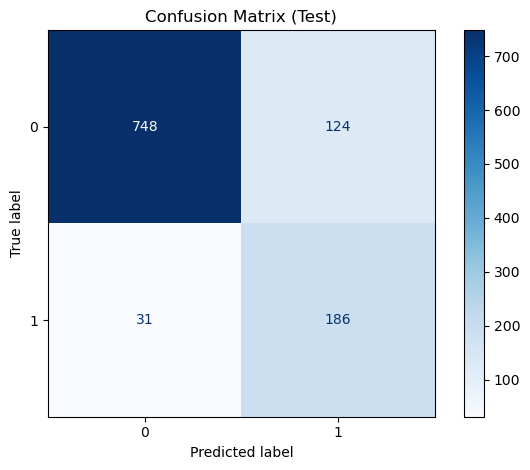

In [12]:
# Evaluation
print(classification_report(y_test, data_test['model_prediction']))

ConfusionMatrixDisplay.from_predictions(
    y_test, data_test['model_prediction'],
    display_labels=[0, 1],
    cmap='Blues'
)
plt.title('Confusion Matrix (Test)')

plt.tight_layout()
plt.show()

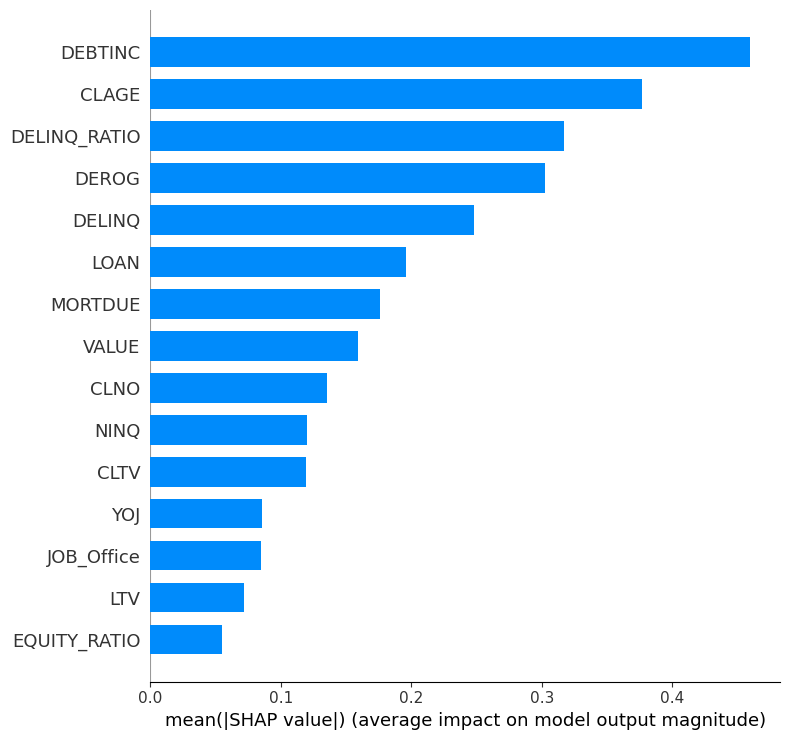

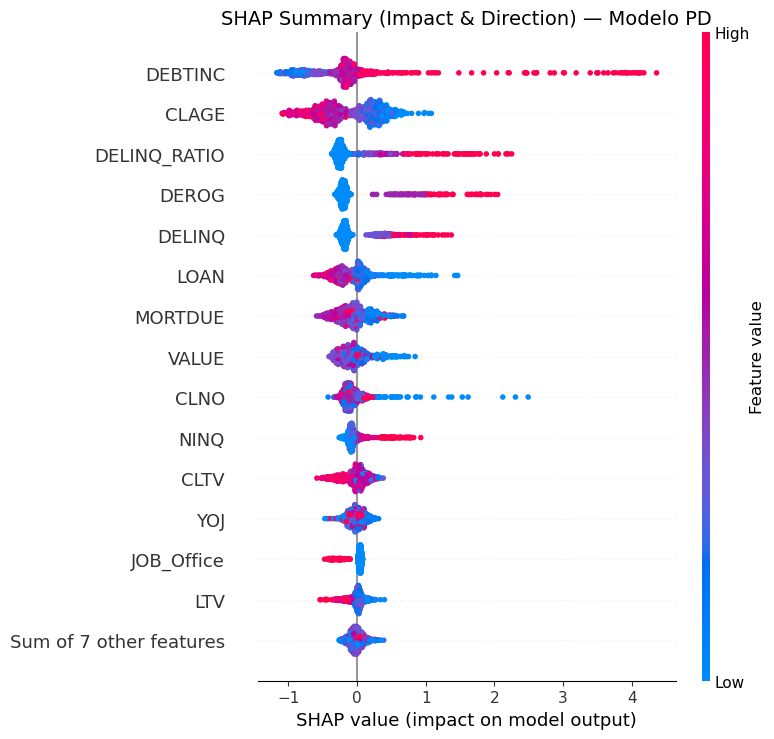

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15,
                  title='SHAP Feature Importance — Modelo PD Hipotecario')

plt.figure(figsize=(10,6))

shap.plots.beeswarm(
    shap_values,
    max_display=15,
    show=False
)

plt.title("SHAP Summary (Impact & Direction) — Modelo PD", fontsize=14)

plt.tight_layout()
plt.show()

In [15]:
print(data_test.LOAN.sum())

20346500.0


In [24]:
31 / (748 + 31)

0.03979460847240052

In [23]:
data_test[(data_test.model_prediction == 0) & (data_test.BAD == 0)]

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,DELINQ_RATIO,UNDERWATER,BAD,LGD,default_proba,EL_pct,EL_amount,model_prediction,amortized_loans,risk_bucket
1061,10100.0,68820.0,78830.0,2.000000,0,0.0,170.722452,1.0,34.0,29.206753,...,0.0,1,0.0,0.140911,0.028995,0.004086,281.177367,0,25856.935478,Low
3817,21700.0,24771.0,48361.0,0.000000,0,0.0,309.028445,1.0,24.0,33.877264,...,0.0,0,0.0,0.000000,0.112783,0.000000,0.000000,0,55554.009888,Medium
2357,15000.0,27954.0,79333.0,3.076486,0,0.0,256.003805,1.0,49.0,42.581949,...,0.0,0,0.0,0.000000,0.089036,0.000000,0.000000,0,38401.389324,Medium
3555,20300.0,37388.0,55703.0,6.966978,0,0.0,222.733567,0.0,12.0,39.814737,...,0.0,1,0.0,0.000000,0.030963,0.000000,0.000000,0,51969.880218,Low
4180,23900.0,70694.0,95718.0,11.000000,0,0.0,138.167360,0.0,13.0,38.561206,...,0.0,0,0.0,0.000000,0.034033,0.000000,0.000000,0,61186.213656,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3954,22400.0,91402.0,100845.0,2.000000,1,0.0,132.216622,0.0,20.0,35.682471,...,0.0,1,0.0,0.172515,0.145114,0.025034,2288.195313,0,57346.074723,Medium
3235,18700.0,58498.0,90135.0,30.000000,0,0.0,199.109272,0.0,21.0,33.182239,...,0.0,0,0.0,0.000000,0.038711,0.000000,0.000000,0,47873.732024,Low
3704,21200.0,130373.0,204384.0,13.000000,0,0.0,197.044461,0.0,21.0,35.204435,...,0.0,0,0.0,0.000000,0.019217,0.000000,0.000000,0,54273.963578,Low
5296,47600.0,39364.0,108232.0,9.000000,0,0.0,199.333286,2.0,35.0,40.189422,...,0.0,0,0.0,0.000000,0.059870,0.000000,0.000000,0,121860.408787,Medium


In [21]:
data_test[(data_test.model_prediction == 0) & (data_test.BAD == 1)]

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,...,DELINQ_RATIO,UNDERWATER,BAD,LGD,default_proba,EL_pct,EL_amount,model_prediction,amortized_loans,risk_bucket
2725,16500.0,94403.00,94428.282292,9.000000,0,1.0,217.786841,0.0,19.000000,30.160826,...,0.050000,1,1.0,0.249799,0.123020,0.030730,2901.037059,0,42241.528256,Medium
447,7300.0,60971.32,77375.000000,2.000000,0,0.0,105.568714,1.0,15.401178,34.997581,...,0.000000,0,1.0,0.048221,0.147193,0.007098,432.756540,0,18688.676138,Medium
3455,20000.0,73400.00,94000.000000,9.000000,0,0.0,270.000000,2.0,14.000000,35.353550,...,0.000000,0,1.0,0.039510,0.027909,0.001103,80.936644,0,51201.852432,Low
1417,11600.0,45917.00,60000.000000,10.000000,0,1.0,304.366667,3.0,27.000000,36.949008,...,0.035714,0,1.0,0.019971,0.144716,0.002890,132.704567,0,29697.074410,Medium
1949,13500.0,70000.00,93500.000000,25.000000,0,0.0,250.633333,0.0,46.000000,34.207156,...,0.000000,0,1.0,0.000000,0.133981,0.000000,0.000000,0,34561.250391,Medium
5384,61400.0,46126.00,83800.000000,33.000000,0,1.0,339.900000,1.0,23.000000,15.940696,...,0.041667,1,1.0,0.000000,0.076925,0.000000,0.000000,0,157189.686965,Medium
2279,15000.0,86000.00,89303.930544,1.000000,0,0.0,63.700000,1.0,27.000000,42.605164,...,0.000000,1,1.0,0.221187,0.147857,0.032704,2812.535250,0,38401.389324,Medium
3664,20900.0,122807.00,150896.000000,5.000000,0,0.0,123.479538,2.0,13.000000,30.424481,...,0.000000,0,1.0,0.078456,0.070146,0.005503,675.852206,0,53505.935791,Medium
2350,15000.0,61265.00,86359.560496,22.000000,0,0.0,186.666667,1.0,21.000000,37.156948,...,0.000000,0,1.0,0.000000,0.127387,0.000000,0.000000,0,38401.389324,Medium
2781,16700.0,77083.00,103540.000000,17.000000,0,0.0,170.812373,1.0,10.000000,37.226431,...,0.000000,0,1.0,0.000000,0.059621,0.000000,0.000000,0,42753.546780,Medium
